In [20]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
import pandas as pd
import numpy as np

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'difficulty'
]

try:
    df_train = pd.read_csv('KDDTrain+.txt', header=None, names=columns)
    df_test = pd.read_csv('KDDTest+.txt', header=None, names=columns)
    print(" Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error:", e)


if 'difficulty' in df_train.columns:
    df_train = df_train.drop('difficulty', axis=1)
    df_test = df_test.drop('difficulty', axis=1)
    print("difficulty column dropped.")
df_train.head()

 Data loaded successfully.
difficulty column dropped.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [22]:
#label encoding 
df = pd.concat([df_train, df_test], axis=0)

X = df.drop(columns=['class'])
y = df['class']
y = y.apply(lambda x: 0 if x == 'normal' else 1)

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
categorical_cols = ['protocol_type', 'service', 'flag']

le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

print("Categorical columns encoded successfully.")


Categorical columns encoded successfully.


In [23]:
# STEP 4: Train-Test Split + Scaling
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data normalized and split successfully.")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Data normalized and split successfully.
Training shape: (118813, 41)
Testing shape: (29704, 41)


In [ ]:
# Feature reduction using correlation matrix

import numpy as np
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_reduced = X.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} highly correlated features.")
print("Remaining features:", X_reduced.shape[1])


Dropped 7 highly correlated features.
Remaining features: 34


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)
top_features = feat_imp['Feature'].head(20)
X_reduced = X[top_features]
print("Top 20 selected features:\n", list(top_features))
print("Final number of features:", X_reduced.shape[1])


Top 20 selected features:
 ['src_bytes', 'dst_bytes', 'flag', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'logged_in', 'diff_srv_rate', 'service', 'dst_host_diff_srv_rate', 'protocol_type', 'count', 'dst_host_same_src_port_rate', 'dst_host_rerror_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_count', 'srv_serror_rate', 'srv_count', 'hot']
Final number of features: 20


In [33]:
# STEP 5: Train-Test Split + Scaling on Reduced Features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_reduced = scaler.fit_transform(X_train_reduced)
X_test_reduced = scaler.transform(X_test_reduced)

print("Train/Test split completed.")
print("Training shape:", X_train_reduced.shape)
print("Testing shape:", X_test_reduced.shape)


Train/Test split completed.
Training shape: (118813, 20)
Testing shape: (29704, 20)


In [34]:
# STEP 6: MODEL TRAINING & EVALUATION
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    acc = accuracy_score(yte, y_pred)
    return acc


In [35]:
# Utility function to plot confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


Decision Tree Accuracy: 0.9940075410719095

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     15411
           1       0.99      0.99      0.99     14293

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



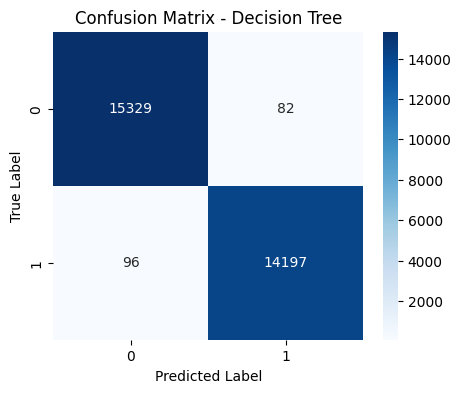

In [36]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_reduced, y_train)

y_pred_dt = dt.predict(X_test_reduced)

acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, zero_division=0))

plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")


KNN Accuracy: 0.990338001615944

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     15411
           1       0.99      0.99      0.99     14293

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



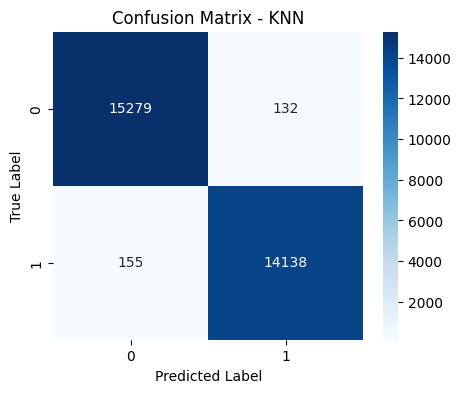

In [37]:
#KNN Classifier
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_reduced, y_train)

y_pred_knn = knn.predict(X_test_reduced)

acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn, zero_division=0))

plot_confusion_matrix(y_test, y_pred_knn, "KNN")


SVM Accuracy: 98.73 %

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     15411
           1       0.99      0.99      0.99     14293

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



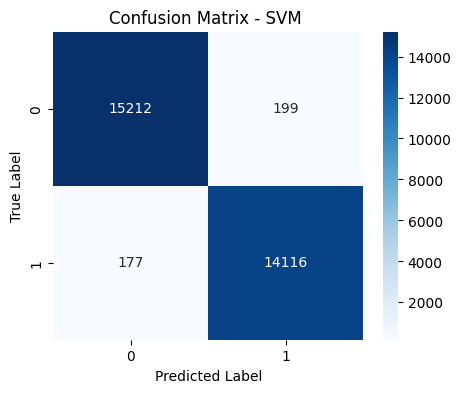

In [38]:
#SVM Classifier 
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

svm = SVC(
    kernel='rbf',           
    C=5,
    gamma=0.05,
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", round(acc_svm * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, zero_division=0))
plot_confusion_matrix(y_test, y_pred_svm, "SVM ")


Random Forest Accuracy: 0.9959264745488823

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     15411
           1       1.00      0.99      1.00     14293

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



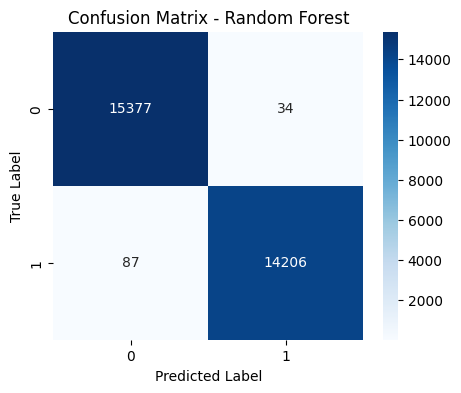

In [39]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_reduced, y_train)

y_pred_rf = rf.predict(X_test_reduced)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
